In [1]:
# This notebook Focuses on Multi-Class Classification Problem using logistic regression

# Algorithm used: RandomForest


# Classification


* A supervised machine learning technique
* Supervised means learn from labeled input data
* Unlike regression which predicts numerical values classification predicts specific groups or categories ( e.g “spam”, “not spam” )




# Types of Classification Problems

**Type 1: Binary Classification**
In binary classification a model predicts exactly one out of the two distinct classes
Examples:  True / False, Pass / Fail , spam / not spam 

**Type 2: Multiclass Classification**
	Predicts exactly one category from three or more discrete options.
Examples:  sorting an image into “dog”, “cat”, or “bird”.

**Type 3: Multilabel Classification**
	Assigns multiple categories to a single data point simultaneously.
Examples: Tagging an article with multiple topics “sports” , “politics”, and “finance”. Or categorizing a movie as both action and comedy.



# Common Algorithms

**Logistic Regression:** It is used for binary classification. It estimates the probability that an observation belongs to a particular class.

**Decision Trees:** Uses a tree-like structure of decisions to split data into categories.

**Support Vector Machines (SVM):** Finds the optimal boundary (hyperplane) that separates different classes in a multi-dimensional space.

**Random Forest:** Combines multiple decision trees to create a more robust and accurate classification model.

**K-Nearest Neighbors (KNN):** Classifies data based on how close it is to the data points  of different classes in the training dataset.

# Evaluation Metrics

**Accuracy:** The ratio of correctly predicted observations to the total observations. ( can be misleading if data is highly imbalanced ).

**Precision:** The ratio of correctly predicted positive observations to the total predicted positives. Essential when false positives are costly.

**Recall(Sensitivity):** The ratio of correctly predicted positive observations to all observations in the actual class. Vital when false negatives are dangerous.

**Confusion Matrics:** A table that outlines the exact number of true positives, True Negatives, False Positives, and False Negatives, allowing for a deep dive into model performance.


In [2]:
# The Iris dataset is a classic toy dataset built into the Scikit-learn -
# library used for teaching and benchmarking machine learning algorithms

# Below I have used the dataset directly from the Scikit-learn library.
# Anyway, both dataset are the same.

In [3]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Load Dataset
iris = load_iris()

X = pd.DataFrame( iris.data, columns=iris.feature_names )
y = iris.target

In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [7]:
# Create model and train model
model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=25,
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=25, random_state=42)

In [8]:
# Predictions
y_pred = model.predict(X_test_scaled)

In [9]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 96.66666666666667


In [10]:
print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



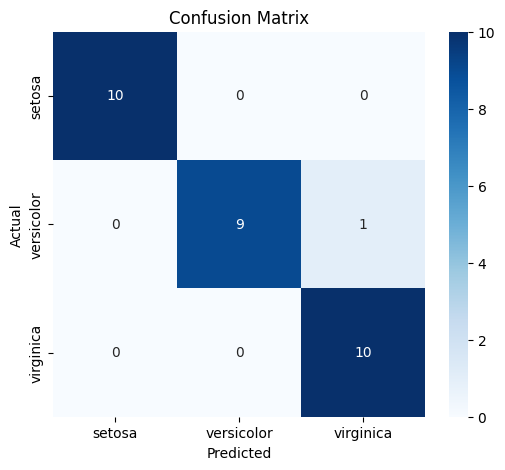

In [11]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
#plt.savefig("cm_logistic_regression.png")
plt.show()